In [250]:
#import libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [251]:
# import database


In [252]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name 
        from sqlite_master
        WHERE type = 'table'

"""

tables = pd.read_sql(sql_query, conn)


# create dataframe for each table 

for table_name in tables['name']:
    df = pd.read_sql(f'SELECT * from {table_name}', conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe : df_{table_name}")

conn.close()

Created dataframe : df_db_customer
Created dataframe : df_db_subscription
Created dataframe : df_db_support


In [253]:
#print the tables names and columns name 
conn = sqlite3.connect("customer_churn.db")

for table_name in tables['name']:
    print(f"\n Table Name : {table_name}")
    # get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns  = pd.read_sql(columns_query, conn)
    print("Columns: ")
    print(columns['name'].tolist())

#close connection
conn.close()


 Table Name : db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name : db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name : db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


### Data Cleaning 

In [254]:
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [255]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


# a. rename column name
# b. drop columns -> 1. interest 2. pincode
# c. change datatype -> dob
# d. data standardization - gender
# e. fix missing values -> countries
# f. 


In [256]:
# a. rename column name

df_db_customer.rename(columns = {'name' : 'customer name'}, inplace = True)   

In [257]:
# b. drop columns -> 1. interest 2. pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)

df_db_customer.drop(axis=1, columns = ["interests", "pincode"], inplace = True)


In [258]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [259]:
# c. change datatype -> dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [260]:
# d. data standardization - gender

df_db_customer['gender'].unique()
df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})


0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: object

In [261]:
# e. fix missing values -> countries

df_db_customer[df_db_customer['country'].isna()]


,customerid,customer name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [262]:
# df_db_customer['country'].fillna('NULL')

df_db_customer[['country',	'state']]

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))


In [263]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [264]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [265]:

# df_db_subscription['renewal_date'] = pd.to_datetime(df_db_subscription['renewal_date'])
# df_db_subscription['subscription_start_date'] = pd.to_datetime(df_db_subscription['subscription_start_date'])
# df_db_subscription['cancellation_date'] = pd.to_datetime(df_db_subscription['cancellation_date'])

date_time_cols = ['renewal_date', 'subscription_start_date', 'cancellation_date']

df_db_subscription[date_time_cols] = df_db_subscription[date_time_cols].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [266]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [267]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [268]:
df_db_support.drop(axis=1, columns = ["col_1", "comment"], inplace = True)


In [269]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [270]:
# Feature Engineering and Data Analysis

In [271]:
df_db_subscription.head(3)
# creating a new colum using current column
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [272]:
df_db_subscription.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [273]:
# firstly fix support shape
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left')
)

In [274]:
df_db_customer.shape

(21, 6)

In [275]:
df.shape
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [276]:
df_db_customer['customerid'].nunique()

21

In [277]:
df_db_subscription['customerid'].nunique()

21

In [278]:
df_db_support['customerid'].nunique()

7

In [279]:
df_db_support['customerid'].size

9

In [280]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [281]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [282]:
df_db_support.shape

(7, 5)

In [283]:
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left')
)

In [284]:
df.to_csv('Exported_churn_data.csv')

In [285]:
# Data Analysis 

In [286]:
# 1. churn RAte

In [287]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [288]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate, 2), "%")

Churn Rate =  28.57 %


In [289]:
# Retaintion Rate 
retaintion_rate = 100 - churn_rate
print("Retantion Rate = ", round(retaintion_rate, 2), "%")

Retantion Rate =  71.43 %


In [290]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [291]:
# 3 churn by plan type 
churn_rate_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pect')
print(churn_rate_plan)

  plan_type  churn_rate_pect
0     Basic            60.00
1   Premium            14.29
2  Standard            22.22


In [292]:
# 4 a. churn by state + sum(revenue) & count of user


In [293]:
hurn_state_plan = df.groupby('state')['churn_flag'].mean()
print(churn_state_plan)

churn_subscription_type = df.groupby('subscription_type')['churn_flag'].mean()
print(churn_subscription_type)

state
Delhi            0.250000
Karnataka        1.000000
Kathmandu        0.000000
Maharashtra      0.000000
Meghalaya        0.666667
Nagaland         0.000000
Rajasthan        0.000000
Telangana        0.500000
Uttar Pradesh    0.000000
Name: churn_flag, dtype: float64
subscription_type
Organic     0.000000
Paid        0.166667
Refferal    0.833333
Name: churn_flag, dtype: float64


In [294]:
# ARPU Avg Renvenue per user

arpu = df['monthly_charges'].mean()
print("ARPU", round(arpu, 2))

ARPU 18.85


In [295]:
# calculate customer age

In [296]:
# 6 AVG Customer Tenure
# count no of days user has use our service : cancellation date else current date 

today = pd.Timestamp.today()
print(today)

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), 

        (df['cancellation_date'] - df['subscription_start_date']).dt.days,
        (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Average tenure days ",round(avg_tenure))

2026-09-11 00:23:47.110206
Average tenure days  1537


In [297]:
# 7 Revenue at risk - revenue last from churn user 
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at risk (Rs K)", revenue_at_risk)

Revenue at risk (Rs K) 73.94


In [298]:
# 8 Esclation Rate 
escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Esclation Rate : ",round(escalation_rate, 2) , "%")

Esclation Rate :  19.05 %


In [299]:
# 9 Avg Complaint Rate per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average Complaint per user " , round(avg_complaints, 2))

Average Complaint per user  0.43


In [300]:
# 10 Correlation Escalation vs Churn 
df['escalations'] = np.where(
    df['escalations'] == 'Y', 1, 0              # encoding string to int type
)
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("correlation betn escalation and churn : ", correlation)

correlation betn escalation and churn :  0.7669649888473702


In [301]:
# 11. churn risk - create a column using existing columns 
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

chioces = ['low', 'medium', 'high']

df['churn_risk'] = np.select(conditions, chioces, default = 'unknown')

In [302]:
df[['churn_risk', 'churn_score']]

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88
5,low,22
6,high,79
7,low,5
8,low,34
9,low,41


In [303]:
### 4 Visualization usgin matplotlib 

In [304]:
df_visual = df.copy()

In [305]:
df_visual.head()
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

cancellation_month
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64


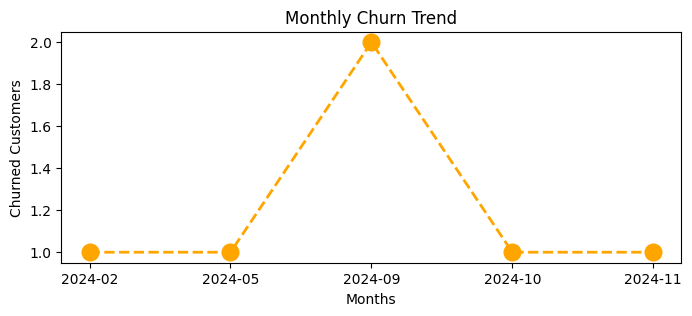

In [306]:
# 4.1 Months churn Trend (Time Seried KPI)

df_visual['cancellation_month']  = df_visual['cancellation_date'].dt.to_period('M')   # for monthly
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
print(churn_trend)

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, marker='o', color='orange', linestyle='dashed', linewidth=2, markersize=12)
plt.title("Monthly Churn Trend")
plt.xlabel("Months")
plt.ylabel("Churned Customers")
plt.show()





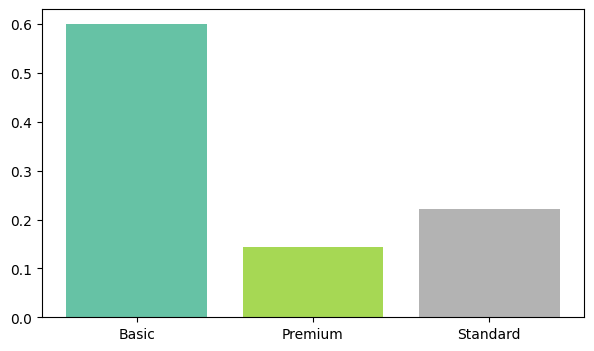

In [307]:
# 4.2 Churn By Plan Type 
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['Red', 'Yellow', 'Green']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7, 4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

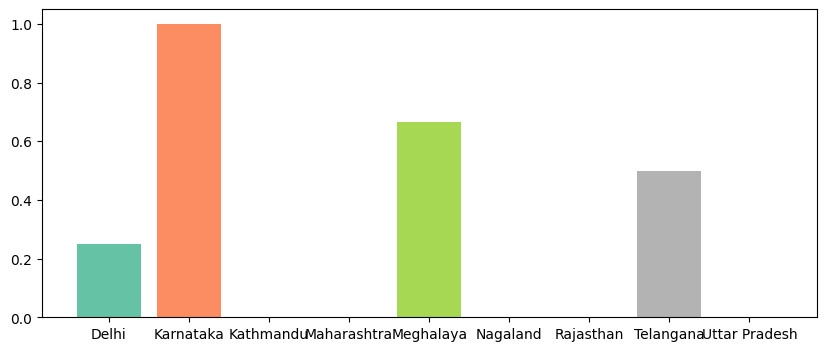

In [308]:
# 4.3 Churn by state 
churn_state = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_state)))
plt.figure(figsize=(10, 4))
plt.bar(churn_state.index, churn_state.values, color = colors)
plt.show()

In [309]:
# Visulaization using seaborn

In [321]:
# encoding - convert str to numeric so that we can find the correlation between feature 

df_visual.columns
df_visual.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2006.0,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1391.0,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2681.0,low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,2024-02


In [315]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [316]:
import warnings
warnings.filterwarnings("ignore")

In [341]:
df_encoded = df_visual[[ 'plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']]

# categorical_cols = ['plan_type', 'contract_type', 'churn_risk']
order_mapping = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'medium', 'high']
} 


for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes


In [337]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [342]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

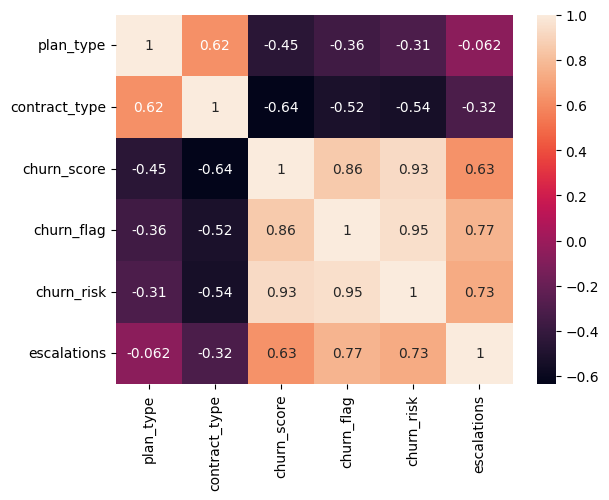

In [343]:
# HeatMap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

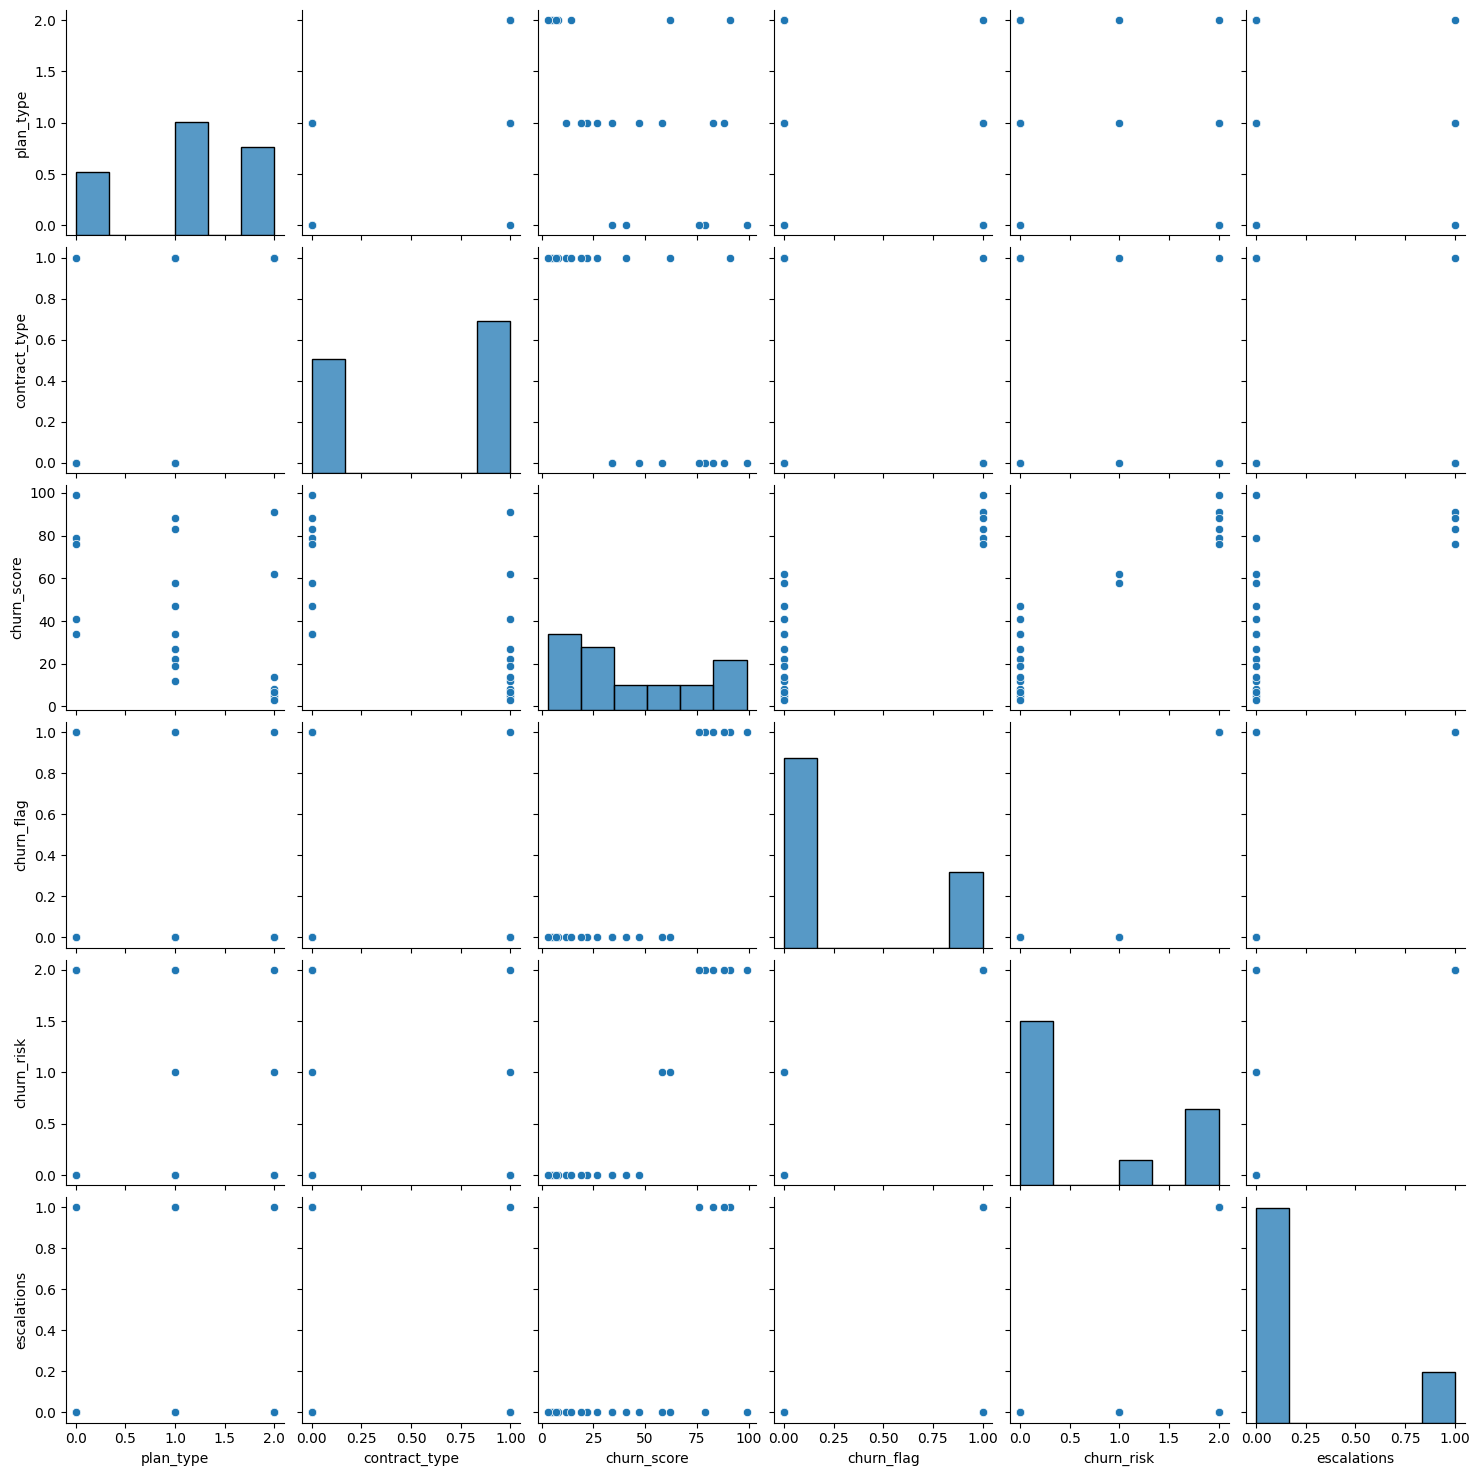

In [344]:
#pair plot
sns.pairplot(df_encoded)

In [346]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

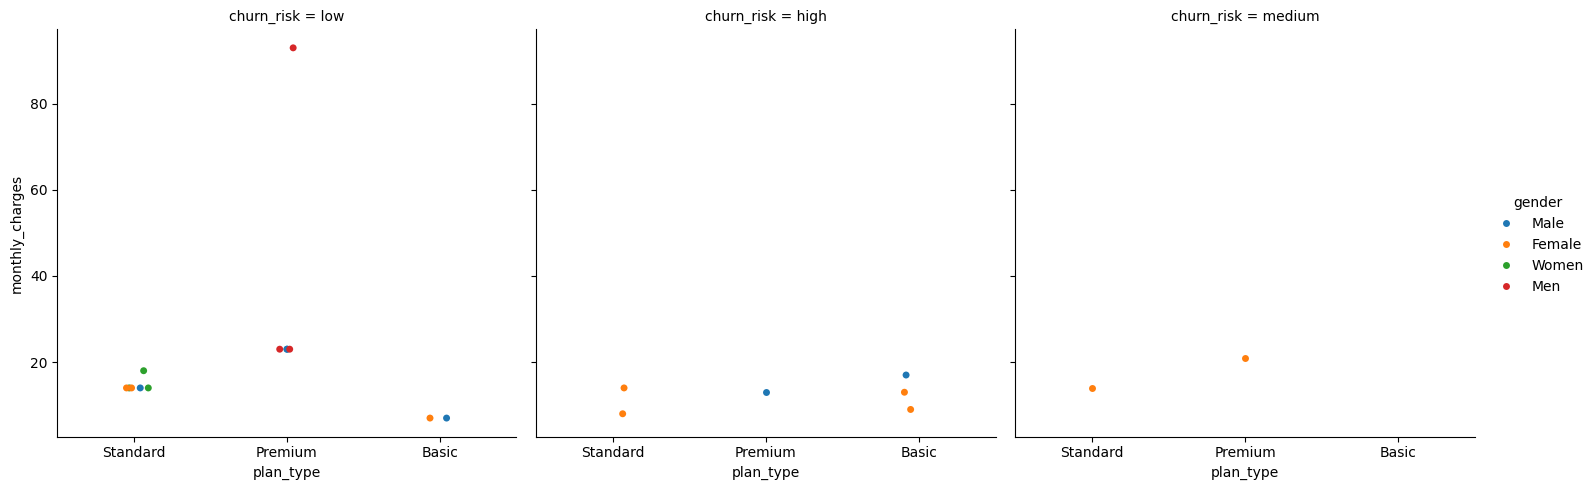

In [349]:
# catplot / Facegrid plot - multi dimension comparision

sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    row=None,
    col='churn_risk'
)

In [350]:
# pivot table

In [352]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [353]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [357]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
# working with sql in python (pandas )

In [359]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

# table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

#commit and save 
conn.commit()

In [365]:
# insert data 
cursor = conn.cursor()
cursor.execute(
    """ 
    INSERT INTO users VALUES
    ('Ram', 'India', 10000),
    ('Sham', 'UK', 20000),
    ('Jan', 'Nepal', 3000)
    
"""
)

conn.commit()
print("Data Inserted Successfully")

Data Inserted Successfully


In [366]:
# Check inserted data in table
conn = sqlite3.connect('test_database.sqlite')

query = """ SELECT * FROM users"""
df_result = pd.read_sql(query, conn)
df_result.head()

,first_name,country,budget
0,Ram,India,10000
1,Sham,UK,20000
2,Jan,Nepal,3000
3,Ram,India,10000
4,Sham,UK,20000


In [368]:
# aggregation

query = """ 
    SELECT country, sum(budget) as total_budget 
    FROM users
    GROUP BY country

"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,India,20000
1,Nepal,6000
2,UK,40000


In [369]:
conn.close()

In [ ]:
df.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [ ]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2005.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1390.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2680.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high
